In [2]:
# 2.1
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) =mnist.load_data()

In [2]:
# 2.2 
train_images.shape
len(train_labels)

60000

### 2.2.6 MANIPULATING TENSORS IN NUMPY

In [3]:
import numpy as np

In [4]:
# 2.19 Slicing a tensor
my_slice = train_images[10:100]
print(my_slice.shape)

(90, 28, 28)


In [5]:
# 2.22 advanced tensor slicing

# in oder to crop our images to paches 14x14 pixels

my_slice = train_images[:, 7:-7, 7:-7]
print(my_slice.shape)

(60000, 14, 14)


### 2.3.1 ELEMENT-WISE OPERATIONS

In [ ]:
# 2.25 element-wise relu operation
def naive_relu(x):
    # x is 2D numpy tensor
    assert len(x.shape) == 2 # 2 axis

    x = x.copy()

    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i , j] = max(x[i, j], 0)

    return x

In [8]:
# 2.26 element-wise addition operation
def naive_add(x , y):
    # x and y is 2D numpy tensor
    assert len(x.shape) == 2
    assert y.shape == x.shape

    x = x.copy()

    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i , j] += y[i , j]

    return x

### 2.3.2 BROADCASTING

In [11]:
# 2.28 naive implementation of matrix-vector addition
def naive_add_matrix_and_vector(x, y):
    # x is 2D numpy tensor
    # y is 1D or numpy vector

    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]

    x = x.copy()

    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i , j] +=y[j]

    return x 

### 2.3.3 TENSOR DOT

In [ ]:
# dot with numpy
import numpy as np
# x and y are numpy vector
z = np.dot(x, y)

In [12]:
# 2.31 naive implementation of dot
def naive_vector_dot(x, y):
    # x and y is numpy vector
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]

    z = 0 # initialize where store output
    for i in range(x.shape[0]):
        z += x[i] * y[i]

    return z 

In [13]:
# 2.32 naive implementation of matrix-vector dot
import numpy as np

def naive_matrix_vector_dot(x , y):
    # x is nuympy matrix
    # y is a numpy vector
    assert len(x.shape) == 2
    assert len(y.shape) == 1

    # 1st dimension of x must be the same as 0th dimension of y
    assert x.shape[1] == y.shape[0]

    # returns a ventors of 0s
    z = np.zeros(x.shape[0])

    for i in range(x.shape[0]):
        for j in range(x.shape[0]):
            z[i] += x[i, j] * y[j]
    
    return z

In [ ]:
# 2.34 naive implementation of matrix-matrix dot

### 2.3.4 TENSOR RESHAPING

In [1]:
import numpy as np

In [3]:
train_images = train_images.reshape((60000, 28 * 28))

In [5]:
# 2.36 tensor reshaping examples
x = np.array([[0. , 1. ]
            ,[2. , 3.]
            ,[4. , 5.]])

print(x.shape)

(3, 2)


In [7]:
x = x.reshape((6, 1))
print(x)

[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]]


In [8]:
x = x.reshape((2, 3))
print(x)

[[0. 1. 2.]
 [3. 4. 5.]]


In [9]:
# 2.37 matrix transposition
x = np.zeros((300, 20))
x = np.transpose(x)
print(x.shape)

(20, 300)


### 2.5 LOOKING BACK ON OUR FIRST EXAMPLE

In [28]:
# load data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [29]:
# preprocess data
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))
# normalizatiom
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255


In [30]:
# import library
from tensorflow import keras
from keras import models, layers

In [31]:
# network
networks = models.Sequential()
# hidden layer
networks.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
# output layer
networks.add(layers.Dense(10, activation='softmax'))

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
from keras.utils import to_categorical

# Misalkan train_labels adalah label asli
train_labels = to_categorical(train_labels, num_classes=10)

In [33]:
# compile
networks.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [36]:
# training loop
history = networks.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9916 - loss: 0.0288
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0211
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9952 - loss: 0.0173
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9972 - loss: 0.0113
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9981 - loss: 0.0087


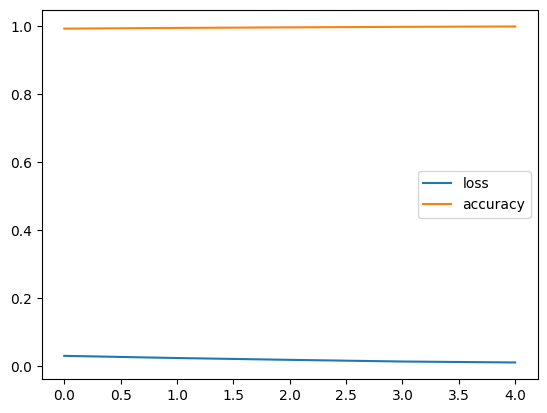

In [37]:
# visualize the model
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.legend()
plt.show()